In [1]:
# Importation des bibliothèques

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from sklearn.metrics import classification_report

In [4]:
# Chemin vers le dossier contenant les images

dataset = "/content/drive/MyDrive/GOMYCODE/dataset"

# Taille des images

IMG_SIZE = (64,64)

# Nombre d'images par lot

BATCH_SIZE = 32

In [5]:

# Chargement des données d'entraînement

train_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)



Found 2427 files belonging to 24 classes.
Using 1942 files for training.


In [6]:
# Chargement des données de validation

val_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)


Found 2427 files belonging to 24 classes.
Using 485 files for validation.


In [7]:
# Nombre de classes

class_names = train_dataset.class_names

NUM_CLASSES = len(class_names)

print(class_names)

['A-samples', 'B-samples', 'C-samples', 'D-samples', 'E-samples', 'F-samples', 'G-samples', 'H-samples', 'I-samples', 'K-samples', 'L-samples', 'M-samples', 'N-samples', 'O-samples', 'P-samples', 'Q-samples', 'R-samples', 'S-samples', 'T-samples', 'U-samples', 'V-samples', 'W-samples', 'X-samples', 'Y-samples']


In [8]:
#Normalisation des images
# Les pixels sont compris entre 0 et 255.
# On les ramène entre 0 et 1.

normalization = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x,y:(normalization(x),y))

val_dataset = val_dataset.map(lambda x,y:(normalization(x),y))

**Premier modèle (sans régularisation)**

In [9]:
#Model sans regularisation

model = Sequential([

    # Première couche de convolution
    Conv2D(32,(3,3),activation="relu",input_shape=(64,64,3)),

    # Réduction de la taille des images
    MaxPooling2D(),

    # Deuxième couche de convolution
    Conv2D(64,(3,3),activation="relu"),

    MaxPooling2D(),

    # Transformation des images en vecteur
    Flatten(),

    # Couche Dense importante
    Dense(256,activation="relu"),

    # Couche de sortie
    Dense(NUM_CLASSES,activation="softmax")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [13]:
#Entrainement

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=10,

    verbose =2


)

Epoch 1/10
61/61 - 42s - 689ms/step - accuracy: 0.3239 - loss: 2.3496 - val_accuracy: 0.4309 - val_loss: 1.9838
Epoch 2/10
61/61 - 8s - 125ms/step - accuracy: 0.5886 - loss: 1.4879 - val_accuracy: 0.5856 - val_loss: 1.4579
Epoch 3/10
61/61 - 7s - 108ms/step - accuracy: 0.7750 - loss: 0.8465 - val_accuracy: 0.7608 - val_loss: 0.8696
Epoch 4/10
61/61 - 8s - 129ms/step - accuracy: 0.9078 - loss: 0.4148 - val_accuracy: 0.8784 - val_loss: 0.5572
Epoch 5/10
61/61 - 7s - 114ms/step - accuracy: 0.9696 - loss: 0.1857 - val_accuracy: 0.9237 - val_loss: 0.4001
Epoch 6/10
61/61 - 11s - 176ms/step - accuracy: 0.9938 - loss: 0.0772 - val_accuracy: 0.9485 - val_loss: 0.3391
Epoch 7/10
61/61 - 6s - 106ms/step - accuracy: 0.9985 - loss: 0.0372 - val_accuracy: 0.9546 - val_loss: 0.3268
Epoch 8/10
61/61 - 7s - 121ms/step - accuracy: 0.9990 - loss: 0.0236 - val_accuracy: 0.9629 - val_loss: 0.3251
Epoch 9/10
61/61 - 6s - 104ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.9649 - val_loss: 0.3257

In [14]:
loss, accuracy = model.evaluate(val_dataset)

print("Accuracy validation :", accuracy)
print("Loss validation :", loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9670 - loss: 0.3307
Accuracy validation : 0.9670103192329407
Loss validation : 0.33069124817848206


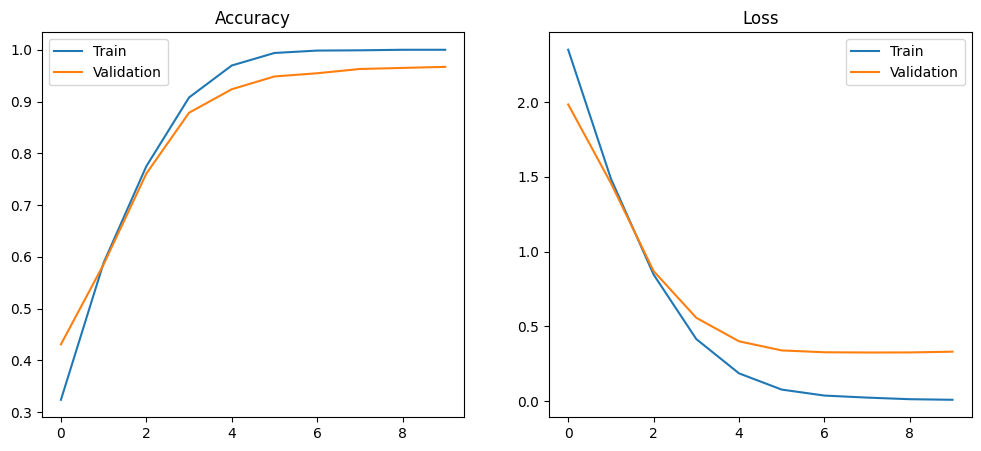

In [15]:
#Afficher la courbe

plt.figure(figsize=(12,5))

# Accuracy

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.legend(["Train","Validation"])

# Loss

plt.subplot(1,2,2)

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.legend(["Train","Validation"])

plt.show()

**Nouveau modèle avec régularisation**

On ajoute :

**Dropout**

**Batch Normalization**

**Data Augmentation**

In [16]:
# Data augmentation

# Création de nouvelles images à partir des images existantes

data_augmentation = tf.keras.Sequential([

    # Petite rotation
    tf.keras.layers.RandomRotation(0.05),

    # Petit zoom
    tf.keras.layers.RandomZoom(0.05)

])

In [17]:
# Modele ameliorer

model_reg = Sequential([

    # Augmentation des données
    data_augmentation,


    # Première convolution
    Conv2D(32,(3,3),activation="relu",input_shape=(64,64,3)),

    # Batch Normalization stabilise l'apprentissage
    BatchNormalization(),

    MaxPooling2D(),

    # Deuxième convolution
    Conv2D(64,(3,3),activation="relu"),

    BatchNormalization(),

    MaxPooling2D(),

    Flatten(),

    Dense(128,activation="relu"),

    # Dropout désactive aléatoirement 30 % des neurones
    Dropout(0.3),

    Dense(NUM_CLASSES,activation="softmax")

])

In [18]:
#Compilation

model_reg.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [19]:
#Arrête automatiquement l'entraînement si la validation n'améliore plus

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [20]:
#Entrainement

history_reg = model_reg.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=20,

    verbose= 2

)

Epoch 1/20
61/61 - 14s - 236ms/step - accuracy: 0.0819 - loss: 4.0010 - val_accuracy: 0.0351 - val_loss: 3.6530
Epoch 2/20
61/61 - 9s - 142ms/step - accuracy: 0.1205 - loss: 3.0217 - val_accuracy: 0.0309 - val_loss: 6.7694
Epoch 3/20
61/61 - 7s - 109ms/step - accuracy: 0.1632 - loss: 2.8282 - val_accuracy: 0.0309 - val_loss: 9.7120
Epoch 4/20
61/61 - 8s - 132ms/step - accuracy: 0.2122 - loss: 2.6385 - val_accuracy: 0.0309 - val_loss: 13.8645
Epoch 5/20
61/61 - 6s - 106ms/step - accuracy: 0.2981 - loss: 2.3046 - val_accuracy: 0.0309 - val_loss: 16.8267
Epoch 6/20
61/61 - 7s - 119ms/step - accuracy: 0.3687 - loss: 1.9960 - val_accuracy: 0.0392 - val_loss: 12.0036
Epoch 7/20
61/61 - 7s - 114ms/step - accuracy: 0.4614 - loss: 1.7049 - val_accuracy: 0.0536 - val_loss: 8.6200
Epoch 8/20
61/61 - 7s - 122ms/step - accuracy: 0.5216 - loss: 1.4410 - val_accuracy: 0.1258 - val_loss: 5.5402
Epoch 9/20
61/61 - 7s - 116ms/step - accuracy: 0.6030 - loss: 1.1888 - val_accuracy: 0.1113 - val_loss: 4.93

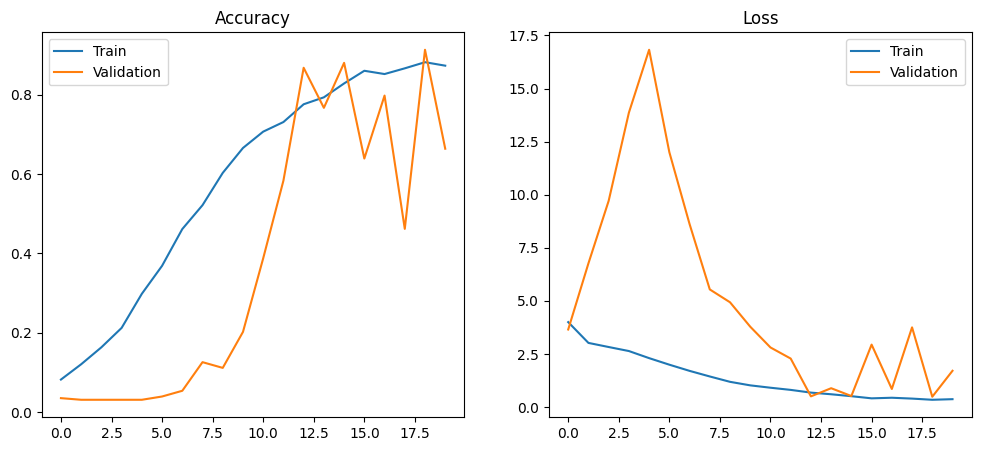

In [21]:
#Courbe

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_reg.history["accuracy"])

plt.plot(history_reg.history["val_accuracy"])

plt.title("Accuracy")

plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(history_reg.history["loss"])

plt.plot(history_reg.history["val_loss"])

plt.title("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [22]:
#Accuracy final

loss, accuracy = model_reg.evaluate(val_dataset)

print("Accuracy :", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6639 - loss: 1.7093
Accuracy : 0.6639175415039062


In [23]:
#Calacul F1

y_true = []
y_pred = []

for images, labels in val_dataset:

    predictions = model_reg.predict(images, verbose=0)

    predictions = np.argmax(predictions, axis=1)

    y_true.extend(labels)

    y_pred.extend(predictions)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   A-samples       0.48      0.69      0.56        16
   B-samples       1.00      0.29      0.44        21
   C-samples       0.57      1.00      0.73        12
   D-samples       0.75      0.60      0.67        15
   E-samples       1.00      0.41      0.58        17
   F-samples       0.61      0.74      0.67        19
   G-samples       0.64      0.93      0.76        27
   H-samples       0.75      1.00      0.86        21
   I-samples       0.46      0.68      0.55        19
   K-samples       0.65      0.65      0.65        20
   L-samples       0.44      1.00      0.62        20
   M-samples       1.00      0.31      0.47        26
   N-samples       0.89      0.44      0.59        18
   O-samples       0.74      1.00      0.85        14
   P-samples       0.68      0.77      0.72        22
   Q-samples       1.00      0.65      0.79        17
   R-samples       0.66      0.68      0.67        28
   S-samples       1.00    

**Avant régularisation :**

Le modèle apprend très bien les images d'entraînement.

La précision d'entraînement est élevée.

La précision de validation est plus faible.

La perte de validation augmente : c'est un signe de surapprentissage.

**Après régularisation :**

Dropout : désactive aléatoirement des neurones pour éviter que le modèle mémorise les données.

Batch Normalization : stabilise et accélère l'entraînement.

Data Augmentation : crée des variantes des images (rotation, retournement), ce qui augmente artificiellement la diversité des données et améliore la généralisation.

In [24]:
# Sauvegarde du modèle

model_reg.save("mnist_cnn.h5")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [25]:
#Sauvegarder les noms des classes

#Streamlit ne connaît pas les noms des classes, il faut aussi les enregistrer.


import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(class_names)

['A-samples', 'B-samples', 'C-samples', 'D-samples', 'E-samples', 'F-samples', 'G-samples', 'H-samples', 'I-samples', 'K-samples', 'L-samples', 'M-samples', 'N-samples', 'O-samples', 'P-samples', 'Q-samples', 'R-samples', 'S-samples', 'T-samples', 'U-samples', 'V-samples', 'W-samples', 'X-samples', 'Y-samples']
